# Plotting

Plotting in ``dmanage.dfmethods`` utilizes the ``Dataframe.Index`` as the xyz bounds and the column for the values. This requires manipulation of the DataFrame in order to plot.

## Generate 1D Data
Let's generate 1D data!

In [22]:
import numpy as np
t = np.linspace(0,10,1000)
y = np.sin(2*np.pi*t)

## Plotting 1D Data

We will plot this traditionally and using `dmanage.dfmethods`

### Traditional Approach

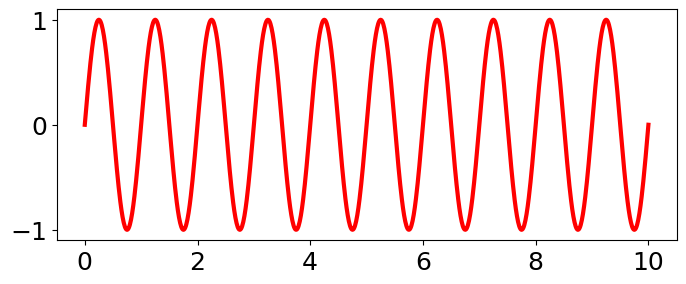

In [23]:
import matplotlib.pyplot as plt
figsize=(8,3)
fig = plt.figure(1, figsize=figsize)
ax = fig.subplots(nrows=1,ncols=1)
ax.plot(t,y)

### DataFrame Methods Approach

               voltage
time                  
0.00000   0.000000e+00
0.01001   6.285329e-02
0.02002   1.254580e-01
0.03003   1.875667e-01
0.04004   2.489336e-01
...                ...
9.95996  -2.489336e-01
9.96997  -1.875667e-01
9.97998  -1.254580e-01
9.98999  -6.285329e-02
10.00000 -2.449294e-15

[1000 rows x 1 columns]


(<Figure size 800x300 with 1 Axes>, <Axes: xlabel='time '>)

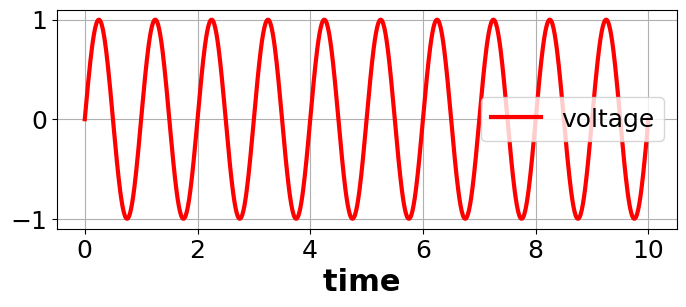

In [24]:
import pandas as pd
from dmanage.dfmethods import plot

df = pd.DataFrame(y,index=t,columns=['voltage'])
df.index.name = 'time'
print(df)
plot.plot1d(df,figsize=figsize)

This function plots the columns vs the index. This also automatically displays the legend. To remove the legend execute `ax.get_legend().remove()`. If there are multiple columns, it'll plot all columns vs index, which will be shown in the next section.

## Plotting 2D Data

here it goes! first lets generate the data

### Generate 2D Data
This is 10 sinusoids with amplitudes ranging from 1 to 0

In [25]:
a = np.linspace(1,0,10)
A,T = np.meshgrid(a,t)
Y = A*np.sin(2*np.pi*T) # something there
print(Y)

[[ 0.00000000e+00  0.00000000e+00  0.00000000e+00 ...  0.00000000e+00
   0.00000000e+00  0.00000000e+00]
 [ 6.28532900e-02  5.58695912e-02  4.88858923e-02 ...  1.39673978e-02
   6.98369889e-03  0.00000000e+00]
 [ 1.25458030e-01  1.11518249e-01  9.75784679e-02 ...  2.78795623e-02
   1.39397811e-02  0.00000000e+00]
 ...
 [-1.25458030e-01 -1.11518249e-01 -9.75784679e-02 ... -2.78795623e-02
  -1.39397811e-02 -0.00000000e+00]
 [-6.28532900e-02 -5.58695912e-02 -4.88858923e-02 ... -1.39673978e-02
  -6.98369889e-03 -0.00000000e+00]
 [-2.44929360e-15 -2.17714987e-15 -1.90500613e-15 ... -5.44287466e-16
  -2.72143733e-16 -0.00000000e+00]]


Y is a 2D array with each column a different amplitude, and the row is time.

### Traditional Approach
First we will plot each sinusoid as 1D plots.

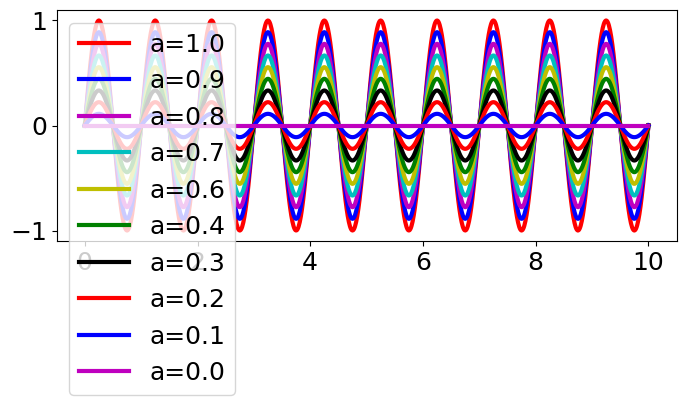

In [26]:
fig = plt.figure(1, figsize=figsize)
ax = fig.subplots(nrows=1,ncols=1)
for i in range(0,Y.shape[1]):
    ax.plot(t,Y[:,i],label='a=%0.1f'%(a[i]))
ax.legend()

10 plots is a lot, and the legend doesnt fit. Also note that instantiating the [dmanage.dfmethods.plot.Plot](../../../api/dmanage.dfmethods.rst#dmanage.dfmethods.plot.Plot) class redefines the matplotlib font size defaults to bigger text. So the font size is bigger even when using the traditional approach. More about that later.

Now lets plot a pcolor plot. The 'p' in 'pcolor' stands for 'psuedo': 'psuedocolor'! 

[Text(0.5, 0, 'Time [s]'), Text(0, 0.5, 'Amplitude')]

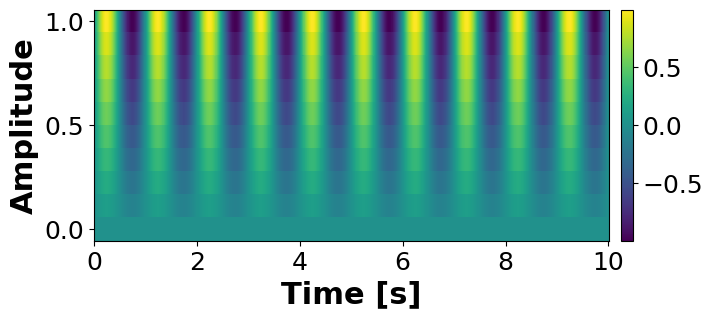

In [27]:
fig = plt.figure(1, figsize=(8,3))
ax = fig.subplots(nrows=1,ncols=1)
pmesh = ax.pcolor(t,a,Y.T)
cbar = fig.colorbar(pmesh,ax=ax,pad=0.02)  # display the colorbar
ax.set(xlabel='Time [s]',ylabel='Amplitude')  # label the axis

This view can be very helpful to visualize many plots! With amplitude of 0, the horizontal line is 0. With an amplitude of 1, the horizontal line goes from 1 to -1.

**_NOTE:_** With the traditional approach we have to manage the 2D array of data, Y, the amplitudes, a, and the time, t. This isn't too much to deal with now, but with more dimensions or when converting coordinate systems, this micromanaging of the dimensions becomes complicated.

### D-Manage Approach

Now we convert our 2D array and bounds 'a' and 't' to a pandas DataFrame

Amplitude      1.000000      0.888889      0.777778      0.666667  \
Time                                                                
0.00000    0.000000e+00  0.000000e+00  0.000000e+00  0.000000e+00   
0.01001    6.285329e-02  5.586959e-02  4.888589e-02  4.190219e-02   
0.02002    1.254580e-01  1.115182e-01  9.757847e-02  8.363869e-02   
0.03003    1.875667e-01  1.667259e-01  1.458852e-01  1.250444e-01   
0.04004    2.489336e-01  2.212743e-01  1.936150e-01  1.659557e-01   
...                 ...           ...           ...           ...   
9.95996   -2.489336e-01 -2.212743e-01 -1.936150e-01 -1.659557e-01   
9.96997   -1.875667e-01 -1.667259e-01 -1.458852e-01 -1.250444e-01   
9.97998   -1.254580e-01 -1.115182e-01 -9.757847e-02 -8.363869e-02   
9.98999   -6.285329e-02 -5.586959e-02 -4.888589e-02 -4.190219e-02   
10.00000  -2.449294e-15 -2.177150e-15 -1.905006e-15 -1.632862e-15   

Amplitude      0.555556      0.444444      0.333333      0.222222  \
Time                             

(<Figure size 1200x500 with 1 Axes>, <Axes: xlabel='Time '>)

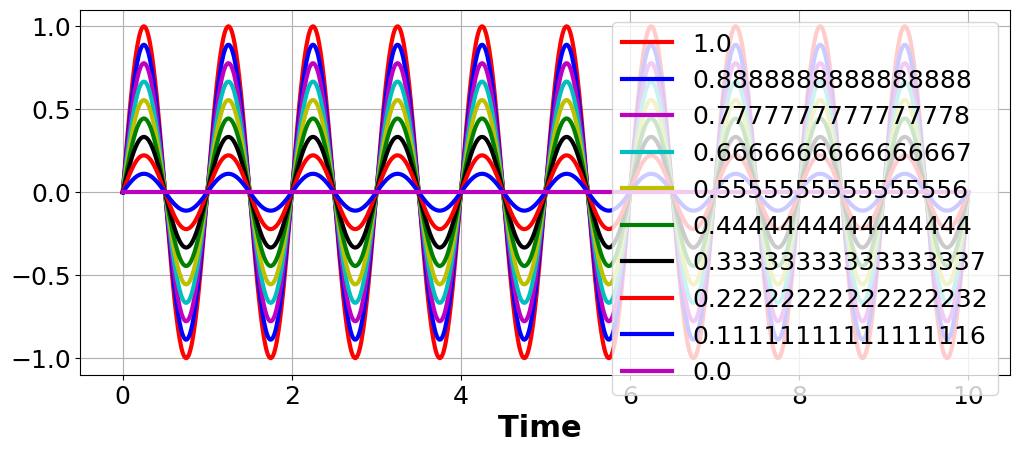

In [28]:
df = pd.DataFrame(Y,columns=a,index=t)
df.columns.name = 'Amplitude'
df.index.name = 'Time'
print(df)
plot.plot1d(df)

The [dmanage.dfmethods.plot.plot1d](../../../api/dmanage.dfmethods.rst#dmanage.dfmethods.plot.plot1d) method can also plot multiple columns of the DataFrame. It automatically generates a legend using the column names; in this case the names are the amplitude values and they are long! We'd possibly want to rename the cols, or we can modify the method to use fewer significant digits! To Do!

Now lets try pcolor. For true 2D plots, there needs to be two indices. So we use the pandas stack method

Time  Amplitude
0.0   1.000000     0.000000e+00
      0.888889     0.000000e+00
      0.777778     0.000000e+00
      0.666667     0.000000e+00
      0.555556     0.000000e+00
                       ...     
10.0  0.444444    -1.088575e-15
      0.333333    -8.164312e-16
      0.222222    -5.442875e-16
      0.111111    -2.721437e-16
      0.000000    -0.000000e+00
Length: 10000, dtype: float64


(<Figure size 1200x500 with 2 Axes>,
 <Axes: xlabel='Time ', ylabel='Amplitude '>,
 <matplotlib.colorbar.Colorbar at 0x792d0e226e90>)

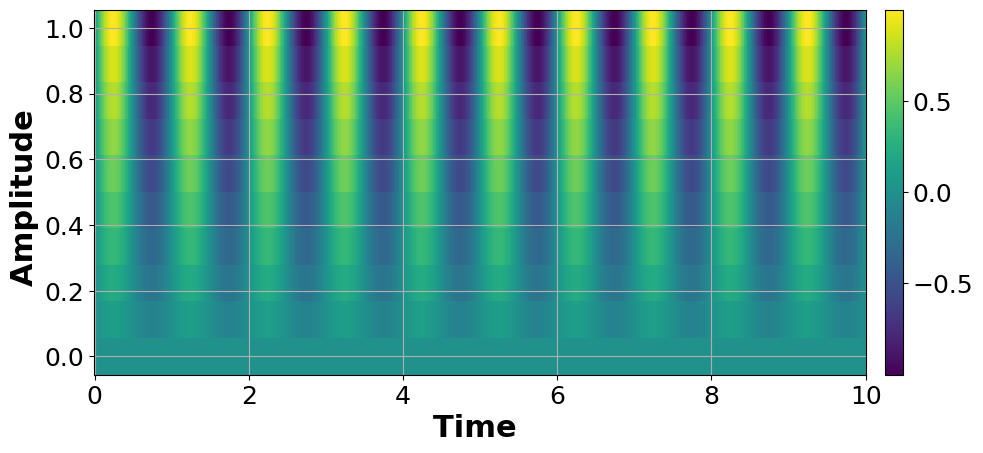

In [29]:
df = df.stack()
print(df)
plot.pcolor(df)

So we got the same result! The D-Manage implementation required converting to a DataFrame, which requires some micromanaging, but generally we aren't generating the data in the script; we are generally reading data from a file. Whatever loader you develope should create this DataFrame as it's return value, instead of the array data and the bounds. This way all the DataFrame creation happens behind the scenes and you have a properly formated DataFrame!

## Plotting 3D Data
Now this is where it gets tricky, how do we visualize 3D data? For 1D data, we needed 2-dimensions to visualize, x and y. With 2D data, we needed 3-dimensions (2 physical dimensions, x and y, and a third 'virtual' dimension, color). So for 3D data, we need 4 dimensions! In this case we can use time as the fourth dimension: make a video! or we can make a 3D color object we can visualize in some other software. To Do!

We organize the DataFrame with 3 indices and one column...


## Plot Font Sizes

How do we change the font sizes in D-Manage?

To Do!